In [2]:
!nvidia-smi

Mon Jun 22 10:49:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!git clone https://github.com/Omid-Nejati/Locality-iN-Locality.git

fatal: destination path 'Locality-iN-Locality' already exists and is not an empty directory.


In [11]:
cd /content/Locality-iN-Locality

/content/Locality-iN-Locality


In [ ]:
pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 16.3 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: re

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

In [2]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [ ]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0   9.9M      0  0:00:26  0:00:26 --:--:-- 16.3M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  9559k      0  0:00:09  0:00:09 --:--:-- 11.0M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0  86908      0  0:00:01  0:00:01 --:--:-- 86928


In [ ]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [4]:
import shutil

In [12]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]


  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [ ]:
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7)
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)

#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]


In [13]:
batch_size = 64

trainset = torchvision.datasets.ImageFolder(root='./data/GTSRB/Final_Training/Images',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.RandomRotation(15),
                                                          transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
                                                          transforms.ToTensor(),
                                                          transforms.RandomErasing(p=0.25),
                                                          ]),
                                               )

testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                         batch_size=batch_size,
                                         shuffle=True,
                                         num_workers=2,
                                         pin_memory=True
                                         )

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                         batch_size=batch_size,
                                         shuffle=False
                                         )

In [15]:
batch = next(iter(train_loader))
train_data = batch[0]

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

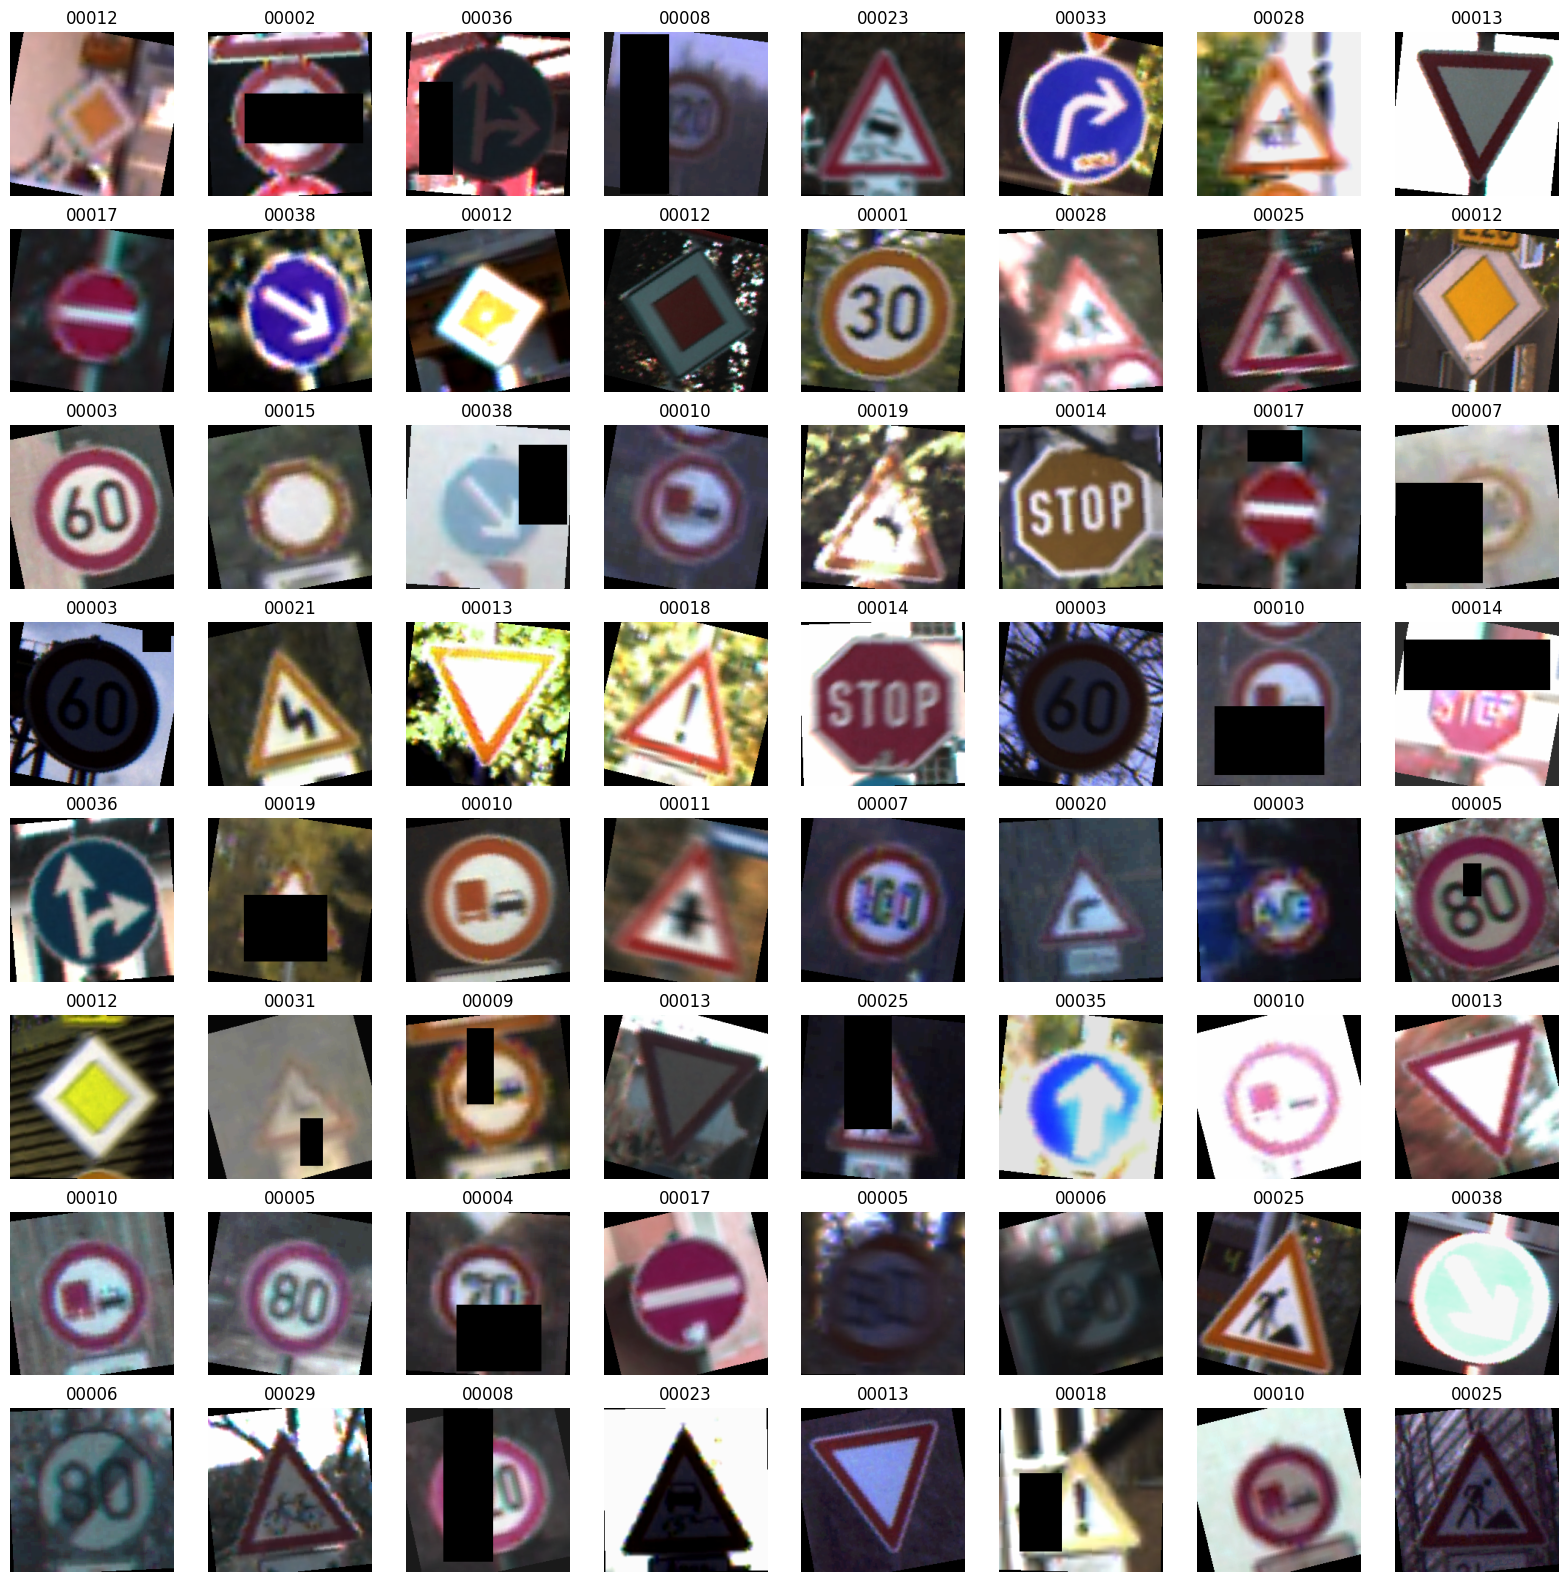

In [ ]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [ ]:
pip install timm

In [ ]:
pip install einops

In [17]:
from LNL import LNL_Ti as small

/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/Locality-iN-Locality/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered

In [18]:
model = small(pretrained=False)

In [19]:
model.head

Linear(in_features=192, out_features=1000, bias=True)

In [20]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [21]:
model = model.cuda()

## Train Locality-iN-Locality

In [24]:
num_epochs = 15

In [25]:
# === Original training setup (SGD) ===
# loss = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

# === Improved training setup (AdamW + Cosine Warmup + Label Smoothing) ===
loss = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)

warmup_epochs = 5
warmup_scheduler = LinearLR(optimizer, start_factor=0.01, total_iters=warmup_epochs)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs, eta_min=1e-6)
scheduler = SequentialLR(optimizer, [warmup_scheduler, cosine_scheduler], milestones=[warmup_epochs])

In [26]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.cuda()
        Y = batch_labels.cuda()

        pre = model(X)
        cost = loss(pre, Y)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

    scheduler.step()

Epoch [1/15], lter [200/612], Loss: 3.731854
Epoch [1/15], lter [400/612], Loss: 3.431441
Epoch [1/15], lter [600/612], Loss: 2.791759
Epoch [2/15], lter [200/612], Loss: 0.787534
Epoch [2/15], lter [400/612], Loss: 0.800142
Epoch [2/15], lter [600/612], Loss: 0.714644
Epoch [3/15], lter [200/612], Loss: 0.789550
Epoch [3/15], lter [400/612], Loss: 0.773743
Epoch [3/15], lter [600/612], Loss: 0.762921
Epoch [4/15], lter [200/612], Loss: 0.811929
Epoch [4/15], lter [400/612], Loss: 0.878191
Epoch [4/15], lter [600/612], Loss: 0.711358
Epoch [5/15], lter [200/612], Loss: 0.758981
Epoch [5/15], lter [400/612], Loss: 0.852432
Epoch [5/15], lter [600/612], Loss: 0.793062
Epoch [6/15], lter [200/612], Loss: 0.733552
Epoch [6/15], lter [400/612], Loss: 0.734857
Epoch [6/15], lter [600/612], Loss: 0.724630
Epoch [7/15], lter [200/612], Loss: 0.808722
Epoch [7/15], lter [400/612], Loss: 0.779752
Epoch [7/15], lter [600/612], Loss: 0.718772
Epoch [8/15], lter [200/612], Loss: 0.782676
Epoch [8/1

In [30]:
import torch

# Define the file path
save_path = 'model_weights.pth'

# Save the model's state dictionary
torch.save(model.state_dict(), save_path)
print(f"Model saved successfully to {save_path}")

Model saved successfully to model_weights.pth


In [22]:
import torch
model.load_state_dict(torch.load('model_weights.pth'))
model = model.cuda()
print("Đã load mô hình thành công!")


Đã load mô hình thành công!


## Test

In [23]:
model.eval()
correct = 0
total = 0

with torch.no_grad(): # Block này bắt buộc phải có để tránh bị OOM lại
    for images, labels in test_loader:
        images = images.cuda()
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels.cuda()).sum()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))


Standard accuracy: 99.78 %


## FGSM attack

In [ ]:
model.eval()

correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

## PGD attack

In [ ]:
model.eval()

correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

## train LNL-MoEx

In [ ]:
from LNL_MoEx import LNL_MoEx_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [ ]:
model = model.cuda()

In [ ]:
import time
# time.clock_gettime()

In [ ]:
num_epochs = 5
moex_lam = .9
moex_prob = .7

In [ ]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [ ]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (input, target) in enumerate(train_loader):
        input = input.cuda()
        target = target.cuda()

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]
            output = model(input, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss(output, target_a) * lam + loss(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model(input)
            # if args.prof >= 0: torch.cuda.nvtx.range_pop()
            cost = loss(output, target)

        # compute gradient and do SGD step

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

## Number of Parameters

In [ ]:
pip install ptflops

In [ ]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

In [ ]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))
